# Unión de modelos

Se propone un procesamiento por capas:

**CAPA 1: PERCEPCIÓN (qué hay en el frame)**
```bash
frame -> [YOLO_players] -> player_tracks (id, bbox)
      -> [YOLO_ball]    -> ball_detections (bbox, conf)
      -> [YOLO_court]   -> court_keypoints          # <- futuro, plug-in
```

**CAPA 2: ENRIQUECIMIENTO (mejorar señales crudas)**
```bash
player_tracks  -> (sin cambios por ahora)
ball_detections -> [Kalman_filter] -> ball_trajectory
court_keypoints -> [Homography] -> court_transform  # <- futuro, necesita capa 1
```

**CAPA 3: CONTEXTO (filtrar y razonar con lo que sabemos)** 
```bash
player_tracks + court_transform -> players_in_court  # <- futuro, necesita capa 2
ball_trajectory + court_transform -> ball_in_court   # <- futuro
```

**CAPA 4: ESTADO UNIFICADO (output consumible)** 
```bash
{
  players:    player_tracks,      # hoy
  ball:       ball_trajectory,    # hoy
  court:      court_transform,    # futuro
  events:     []                  # futuro (saque, golpe, out...)
}
```

In [ ]:
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import seaborn as sns
import numpy as np
from PIL import Image
from torchvision import models, transforms
from ultralytics import YOLO
import cv2
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm


In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Versión de CUDA en PyTorch: {torch.version.cuda}")

if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Número de GPUs detectadas: {num_gpus}")
    for i in range(num_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        # capacidad de cómputo
        capability = torch.cuda.get_device_capability(i)
        print(f"  Capacidad de cómputo: {capability[0]}.{capability[1]}")
else:
    print("No se detectaron GPUs con soporte CUDA.")

PyTorch version: 2.5.1+cu121
CUDA disponible: True
Versión de CUDA en PyTorch: 12.1
Número de GPUs detectadas: 1
  GPU 0: NVIDIA GeForce RTX 3070 Ti Laptop GPU
  Capacidad de cómputo: 8.6


In [3]:
def perception_layer(
    ball_model_path: str,
    players_model_path: str,
    kps_model_path: str,
    video_path: str,
    output_path: str = "output_perception.mp4",
    conf: float = 0.35,
    imgsz: int = 240,
    device: int | str = 0,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    # Load keypoints model
    kps_model = models.resnet50()
    kps_model.fc = torch.nn.Linear(kps_model.fc.in_features, 14 * 2)
    load_best_model_tennis_court_detector(kps_model_path, kps_model)
    kps_model = kps_model.to(device)

    ball_model    = YOLO(ball_model_path)
    players_model = YOLO(players_model_path)

    transforms_pipeline = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    cap    = cv2.VideoCapture(video_path)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height),
    )

    print(f"--- Iniciando perception layer: {video_path} ---")

    ball_rows   = []
    player_rows = []
    frame_idx   = 0

    kps_model.eval()
    with torch.no_grad():
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_idx += 1

            ball_result = ball_model.predict(
                frame, conf=conf, imgsz=imgsz, device=device, verbose=False
            )[0]
            players_result = players_model.track(
                frame, conf=conf, imgsz=imgsz, device=device, verbose=False, persist=True, classes=[0]
            )[0]

            frame_rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            input_tensor = transforms_pipeline(frame_rgb).unsqueeze(0).to(device)
            kps          = kps_model(input_tensor).squeeze().cpu().numpy()
            kps[::2]  *= width  / 224.0
            kps[1::2] *= height / 224.0

            ball_rows.append(_parse_ball_result(ball_result, frame_idx))
            player_rows.extend(_parse_player_result(players_result, frame_idx))

            annotated = _draw_frame(frame, ball_result, players_result)
            for i in range(0, len(kps), 2):
                x, y = int(kps[i]), int(kps[i + 1])
                cv2.circle(annotated, (x, y), radius=5, color=(0, 255, 0), thickness=-1)

            writer.write(annotated)

    cap.release()
    writer.release()

    print(f"  Video guardado en : {output_path}")
    print(f"  Total frames      : {frame_idx}\n")

    return pd.DataFrame(ball_rows), pd.DataFrame(player_rows)


#==========================================================================
#  best model tennis court key points detector 
#==========================================================================

def load_best_model_tennis_court_detector(path, model, optimizer=None):
    ckpt = torch.load(path, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    if optimizer:
        optimizer.load_state_dict(ckpt["optimizer"])
    return ckpt["epoch"], ckpt["metrics"]

#==========================================================================
#  Parsers 
#==========================================================================

def _parse_ball_result(r, frame_idx: int) -> dict:
    """Extrae datos de pelota de un resultado YOLO (un frame)."""
    no_det = r.boxes is None or len(r.boxes) == 0

    if no_det:
        return _empty_ball_row(frame_idx)

    confs  = r.boxes.conf.tolist()
    bboxes = r.boxes.xyxy.tolist()
    best   = int(pd.Series(confs).idxmax())
    x1, y1, x2, y2 = bboxes[best]

    return {
        "frame"          : frame_idx,
        "ball_detected"  : True,
        "conf"           : round(confs[best], 4),
        "x1": round(x1, 2), "y1": round(y1, 2),
        "x2": round(x2, 2), "y2": round(y2, 2),
        "cx"             : round((x1 + x2) / 2, 2),
        "cy"             : round((y1 + y2) / 2, 2),
        "width"          : round(x2 - x1, 2),
        "height"         : round(y2 - y1, 2),
        "multi_detection": len(confs) > 1,
    }


def _parse_player_result(r, frame_idx: int) -> list[dict]:
    """Extrae datos de jugadores de un resultado YOLO tracking (un frame)."""
    if r.boxes is None or r.boxes.id is None:
        return []

    ids    = r.boxes.id.int().tolist()
    confs  = r.boxes.conf.tolist()
    bboxes = r.boxes.xyxy.tolist()

    rows = []
    for pid, conf, (x1, y1, x2, y2) in zip(ids, confs, bboxes):
        rows.append({
            "frame"    : frame_idx,
            "player_id": pid,
            "conf"     : round(conf, 4),
            "x1": round(x1, 2), "y1": round(y1, 2),
            "x2": round(x2, 2), "y2": round(y2, 2),
            "cx"       : round((x1 + x2) / 2, 2),
            "cy"       : round((y1 + y2) / 2, 2),
            "width"    : round(x2 - x1, 2),
            "height"   : round(y2 - y1, 2),
        })
    return rows


#  Drawing 

# Paleta de colores por player_id (BGR)
_PLAYER_COLORS = [
    (255, 100, 0), (0, 200, 255), (0, 255, 100),
    (200, 0, 255), (255, 200, 0), (0, 100, 255),
]

def _draw_frame(
    frame: np.ndarray,
    ball_result,
    players_result,
) -> np.ndarray:
    """Dibuja detecciones de pelota y jugadores sobre el frame."""
    out = frame.copy()
    _draw_ball(out, ball_result)
    _draw_players(out, players_result)
    return out


def _draw_ball(frame: np.ndarray, r) -> None:
    """Dibuja bbox de la pelota (amarillo)."""
    if r.boxes is None or len(r.boxes) == 0:
        return

    confs  = r.boxes.conf.tolist()
    bboxes = r.boxes.xyxy.tolist()
    best   = int(pd.Series(confs).idxmax())
    x1, y1, x2, y2 = [int(v) for v in bboxes[best]]

    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 2)
    cv2.putText(
        frame, f"ball {confs[best]:.2f}",
        (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1,
    )


def _draw_players(frame: np.ndarray, r) -> None:
    """Dibuja bbox y player_id por jugador (color único por ID)."""
    if r.boxes is None or r.boxes.id is None:
        return

    ids    = r.boxes.id.int().tolist()
    confs  = r.boxes.conf.tolist()
    bboxes = r.boxes.xyxy.tolist()

    for pid, conf, (x1, y1, x2, y2) in zip(ids, confs, bboxes):
        color = _PLAYER_COLORS[pid % len(_PLAYER_COLORS)]
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            frame, f"P{pid} {conf:.2f}",
            (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2,
        )

def _empty_ball_row(frame_idx: int) -> dict:
    """Fila vacía para frames sin detección."""
    nan = float("nan")
    return {
        "frame"          : frame_idx,
        "ball_detected"  : False,
        "conf"           : nan,
        "x1"             : nan, "y1": nan,
        "x2"             : nan, "y2": nan,
        "cx"             : nan, "cy": nan,
        "width"          : nan, "height": nan,
        "multi_detection": False,
    }

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
ruta_video_prueba = "../data/tennis_match.mp4"

ball_df, players_df = perception_layer(
    ball_model_path    = '../best_models/best_tennis_ball_detection.pt',
    players_model_path = '../best_models/best_tennis_player_tracking.pt',
    kps_model_path     = '../best_models/best_court_key_points_detection.pth',
    video_path         = ruta_video_prueba,
    output_path        = "output.mp4",
    conf               = 0.25,
    imgsz              = 640,
    device             = device,
)

print(ball_df.head())
print(players_df.head())

C:\Users\sprou\AppData\Local\Temp\ipykernel_24868\533939860.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location="cpu")


--- Iniciando perception layer: ../data/tennis_match.mp4 ---
  Video guardado en : output.mp4
  Total frames      : 224

   frame  ball_detected    conf       x1      y1       x2      y2       cx  \
0      1          False     NaN      NaN     NaN      NaN     NaN      NaN   
1      2           True  0.2897  1015.66  140.16  1028.41  153.31  1022.03   
2      3          False     NaN      NaN     NaN      NaN     NaN      NaN   
3      4          False     NaN      NaN     NaN      NaN     NaN      NaN   
4      5          False     NaN      NaN     NaN      NaN     NaN      NaN   

       cy  width  height  multi_detection  
0     NaN    NaN     NaN            False  
1  146.73  12.75   13.15            False  
2     NaN    NaN     NaN            False  
3     NaN    NaN     NaN            False  
4     NaN    NaN     NaN            False  
   frame  player_id    conf       x1      y1       x2       y2       cx  \
0      1          1  0.9322   347.79  803.29   494.93  1054.91   421.36

In [5]:
def predict_image_full(
    ball_model_path: str,
    players_model_path: str,
    kps_model_path: str,
    image_path: str,
    conf: float = 0.25,
    imgsz: int = 640,
    device: int | str = 0,
) -> None:

    # Load keypoints model
    kps_model = models.resnet50()
    kps_model.fc = torch.nn.Linear(kps_model.fc.in_features, 14 * 2)
    load_best_model_tennis_court_detector(kps_model_path, kps_model)
    kps_model = kps_model.to(device)

    ball_model    = YOLO(ball_model_path)
    players_model = YOLO(players_model_path)

    transforms_pipeline = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    frame = cv2.imread(image_path)
    h, w  = frame.shape[:2]

    # YOLO models
    ball_result    = ball_model.predict(frame, conf=conf, imgsz=imgsz, device=device, verbose=False)[0]
    players_result = players_model.track(frame, conf=conf, imgsz=imgsz, device=device, verbose=False, persist=True, classes=[0])[0]

    # Keypoints model
    kps_model.eval()
    with torch.no_grad():
        frame_rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        input_tensor = transforms_pipeline(frame_rgb).unsqueeze(0).to(device)
        kps          = kps_model(input_tensor).squeeze().cpu().numpy()
        kps[::2]  *= w / 224.0
        kps[1::2] *= h / 224.0

    # Draw
    annotated = _draw_frame(frame, ball_result, players_result)
    for i in range(0, len(kps), 2):
        x, y = int(kps[i]), int(kps[i + 1])
        cv2.circle(annotated, (x, y), radius=5, color=(0, 255, 0), thickness=-1)
        cv2.putText(annotated, str(i // 2), (x + 6, y - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

    # Show
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Ball  |  Players  |  Court Keypoints")
    plt.tight_layout()
    plt.show()

C:\Users\sprou\AppData\Local\Temp\ipykernel_24868\533939860.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location="cpu")


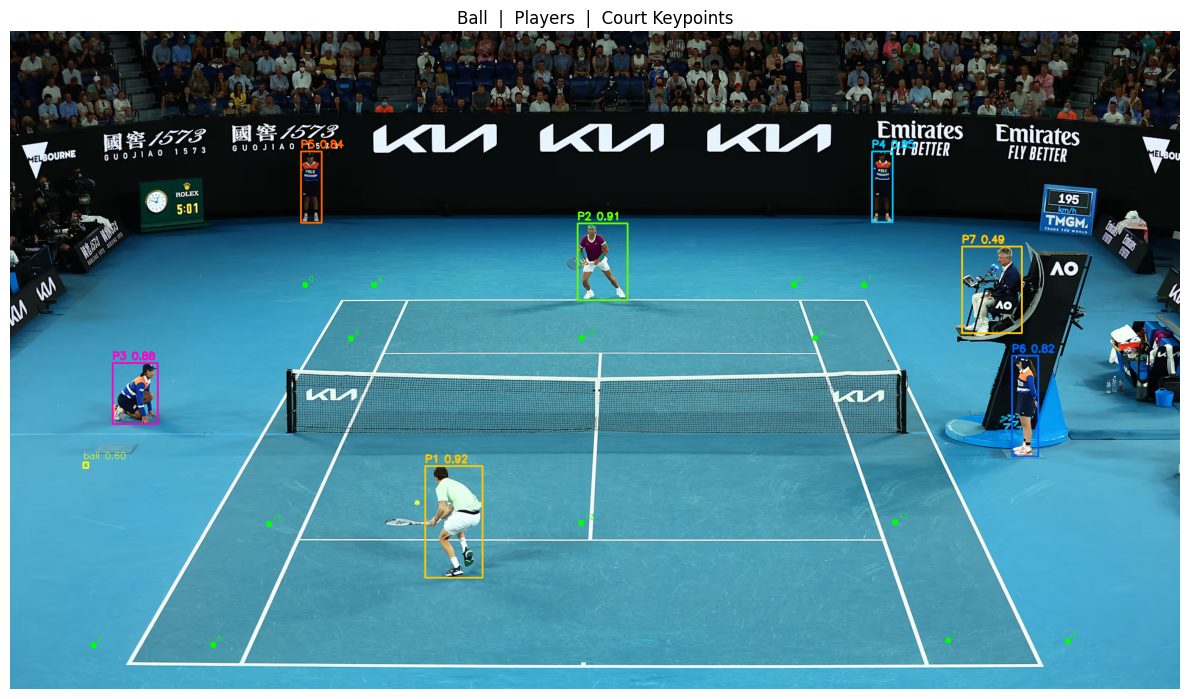

In [9]:
predict_image_full(
    ball_model_path    = '../best_models/best_tennis_ball_detection.pt',
    players_model_path = '../best_models/best_tennis_player_tracking.pt',
    kps_model_path     = '../best_models/best_court_key_points_detection.pth',
    image_path         = '../data/tennis_match.jpg',
    conf               = 0.25,
    imgsz              = 640,
    device             = device,
)